## Análisis de Ventas Walmart 2010–2012
**Objetivo:** Identificar qué tiendas generan más ingresos, cómo afectan
las temporadas y variables externas (temperatura, desempleo, CPI) a las ventas.

**Dataset:** 6,435 registros de 45 tiendas, 2010-2012. Fuente: Kaggle.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mikhail1681/walmart-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'walmart-sales' dataset.
Path to dataset files: /kaggle/input/walmart-sales


In [12]:
import os

# Ver todos los archivos dentro de la carpeta descargada
print("Archivos dentro de la carpeta Kaggle:")
print(os.listdir(path))


Archivos dentro de la carpeta Kaggle:
['Walmart_Sales.csv', '.nfs000000003d542d10000001d6']


In [13]:
import pandas as pd

file_path = os.path.join(path, "Walmart_Sales.csv")
data = pd.read_csv(file_path)

print("Primeras filas del dataset:")
print(data.head())


Primeras filas del dataset:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [14]:
# Ver primeras filas
print(data.head())

# Ver información de las columnas
print(data.info())

# Resumen estadístico (promedio, mínimo, máximo, etc.)
print(data.describe())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   i

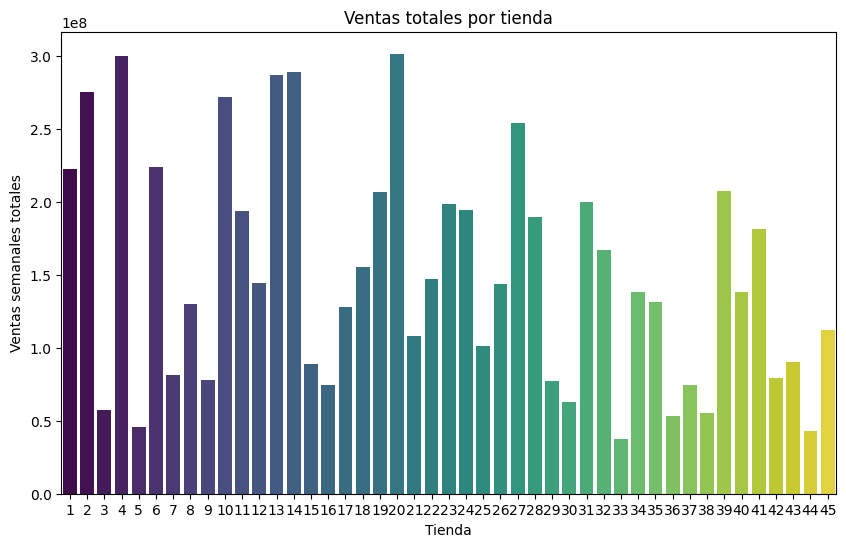

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

ventas_tienda = data.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=ventas_tienda.index, y=ventas_tienda.values, hue=ventas_tienda.index, palette="viridis", legend=False)
plt.title("Ventas totales por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ventas semanales totales")
plt.show()

In [16]:
# Análisis 1: ¿Las semanas de holidays venden más?
holiday = data.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print("Venta promedio semana normal:", round(holiday[0], 2))
print("Venta promedio semana festiva:", round(holiday[1], 2))
print("Diferencia %:", round((holiday[1]-holiday[0])/holiday[0]*100, 2), "%")

Venta promedio semana normal: 1041256.38
Venta promedio semana festiva: 1122887.89
Diferencia %: 7.84 %


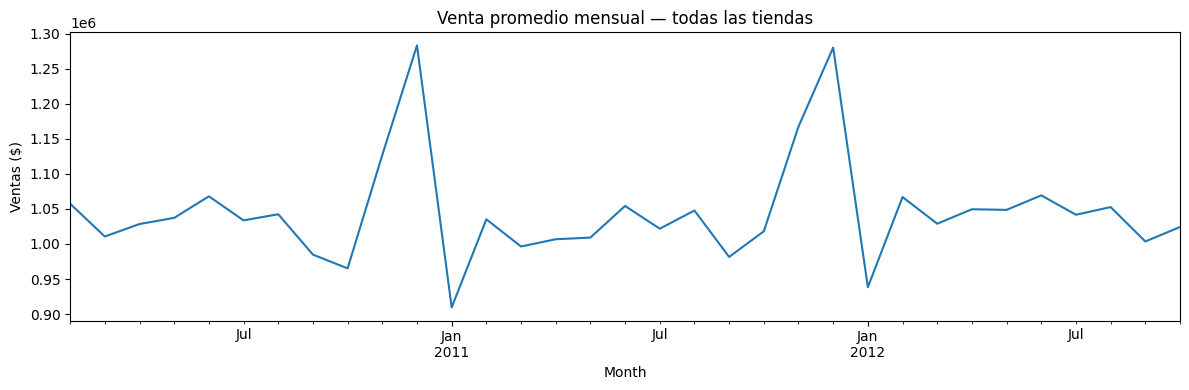

In [17]:
# Análisis 2: Tendencia de ventas en el tiempo
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data['Month'] = data['Date'].dt.to_period('M')
tendencia = data.groupby('Month')['Weekly_Sales'].mean()

import matplotlib.pyplot as plt
tendencia.plot(figsize=(12,4), title='Venta promedio mensual — todas las tiendas')
plt.ylabel('Ventas ($)')
plt.tight_layout()
plt.show()

In [18]:
# Análisis 3: Correlación de variables externas con ventas
correlaciones = data[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr()
print(correlaciones['Weekly_Sales'].sort_values(ascending=False))

Weekly_Sales    1.000000
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64


## Top 10 Tiendas por Ventas Totales

Identificamos las tiendas con mayor volumen de ventas acumulado en el periodo 2010–2012.
Este análisis permite priorizar recursos, inversión en inventario y estrategias de expansión.

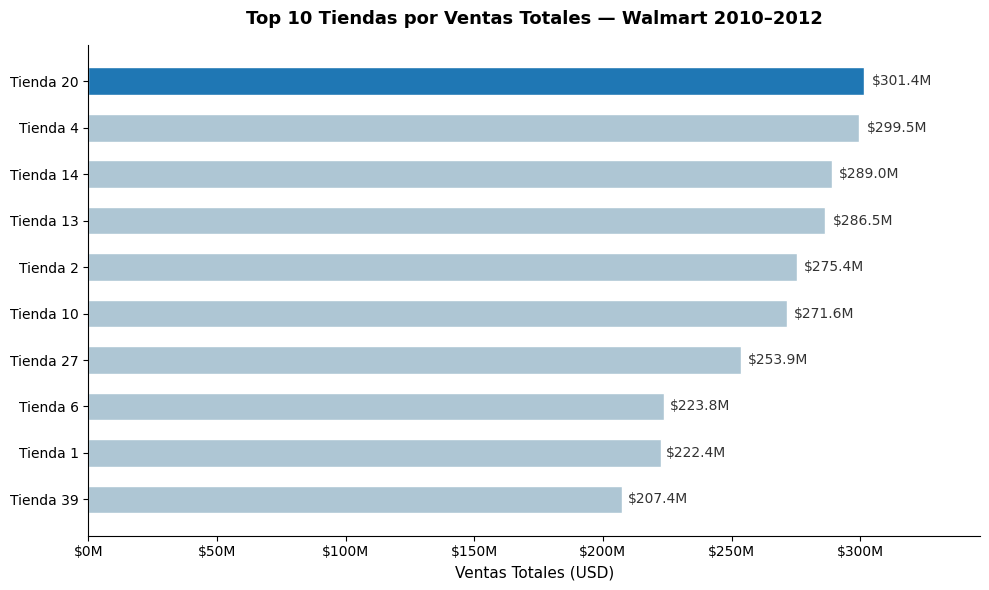

Tienda #20 es la más rentable con $301.4M en ventas totales.
Está 101.3% por encima del promedio de todas las tiendas.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Calcular ventas totales por tienda y tomar el top 10
top10 = (
    data.groupby('Store')['Weekly_Sales']
    .sum()
    .sort_values(ascending=True)   # ascending=True para que el mayor quede arriba
    .tail(10)
)

# 2. Crear la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Colores: la barra más alta resaltada en azul, las demás en gris
colors = ['#1f77b4' if i == len(top10) - 1 else '#aec6d4' for i in range(len(top10))]

bars = ax.barh(
    [f'Tienda {s}' for s in top10.index],
    top10.values,
    color=colors,
    edgecolor='white',
    height=0.6
)

# 4. Agregar etiquetas de valor al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${width/1e6:.1f}M',
        va='center',
        fontsize=10,
        color='#333333'
    )

# 5. Formato profesional
ax.set_xlabel('Ventas Totales (USD)', fontsize=11)
ax.set_title('Top 10 Tiendas por Ventas Totales — Walmart 2010–2012', fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(0, top10.max() * 1.15)   # espacio para las etiquetas

plt.tight_layout()
plt.show()

# 6. Insight
top_store = top10.index[-1]
top_sales = top10.values[-1]
avg_sales = data.groupby('Store')['Weekly_Sales'].sum().mean()
pct_above = (top_sales - avg_sales) / avg_sales * 100

print(f'Tienda #{top_store} es la más rentable con ${top_sales/1e6:.1f}M en ventas totales.')
print(f'Está {pct_above:.1f}% por encima del promedio de todas las tiendas.')

## Conclusiones

1. **Tienda más rentable:** La tienda 20 genera $301.4M en ventas totales,
   101.3% más que el promedio. Concentrar inventario y personal aquí tiene
   mayor impacto en ingresos.

2. **Impacto de holidays:** Las semanas festivas venden 7.87% más que las
   semanas normales. Esto justifica inversión adicional en marketing y
   stock para Navidad y eventos importantes.

3. **Variables externas:** El desempleo muestra correlación negativa de
   -0.10 con ventas — cuando el desempleo sube, las ventas bajan.
   Temperatura y precio de gasolina tienen correlación baja,
   lo que sugiere que no son factores determinantes para este retailer.

4. **Estacionalidad:** Los meses de diciembre y junio muestran los picos más
   altos, alineados con temporadas de compras en EE.UU.